# Customer Churn Prediction

This project contains:
* Analysis of data
* Data exploration
* Data Cleaning
* Data Visulaization
* Applicability of machine Learning Algorithm
* Deployment of the complete oerational prediction model using streamlit.

Let's get started, I'll try to keep my whole data synced with github repo.

Our goal is to predict, whether the customer who is using or relying on the product will churn or not from the service or platform.

In [96]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

I'll import the libraries and tools for ML algorithms further.

In [97]:
# creating and reading the datafame using pandas:
# Loading the dataset:
df = pd.read_csv(r'C:\Users\Nikhil Pandey\OneDrive\Desktop\PROGRAM\Projects\Customer_Churn_Prediction\data\customer_churn_data.csv')

In [98]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


# EDA: 
Let's perform EDA and get to know about the hidden insights and take an overall veiw of the dataset.

I'm using y_data_profiling to perform EDA. Just using it for my own sake. So that I can have a broder overview on the whole dataset.

In [99]:
!pip install ydata_profiling --quiet

from ydata_profiling import ProfileReport
profile = ProfileReport(df)

profile.to_file('eda_report.html')

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 106.02it/s]


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [101]:
df.shape

(1000, 10)

In [102]:
df.tail(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
998,999,39,Male,68,65.67,One-Year,NaN,4465.56,No,Yes
999,1000,50,Male,1,56.67,Month-to-Month,NaN,56.67,No,Yes


I can see there is some missing terms in section of InternetService type, which is a categorical data type.

In [103]:
df.isna().sum().sum()

np.int64(297)

In [104]:
df['InternetService'].isna().sum()

np.int64(297)

In [105]:
# Let's impute this column
df['InternetService'] = df['InternetService'].fillna("")

In [106]:
df.isna().sum().sum()

np.int64(0)

In [107]:
# Checking for duplicated values
df.duplicated().sum()

np.int64(0)

In [108]:
# Mathematical aspects of df:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [109]:
numeric_columns_data = df.select_dtypes(include=['number'])

In [110]:
numeric_columns_data.corr()  # Correlation between numerical columns

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


* -1 means Strong Negative
* 1 menas strong psotive

In [111]:
df['Churn'].value_counts()

Churn
Yes    883
No     117
Name: count, dtype: int64

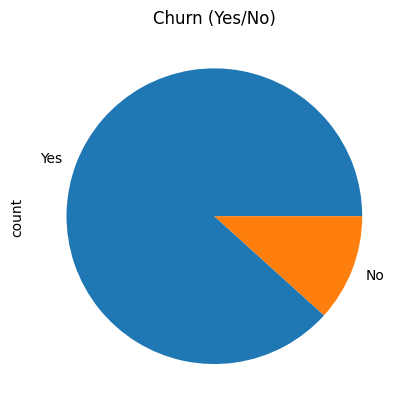

In [112]:
# Let's visualize the above churn count
df['Churn'].value_counts().plot(kind='pie')
plt.title("Churn (Yes/No)")
plt.xlabel('')

plt.savefig('charts/img_1')

In [113]:
# Let's see our monthly charges with respect to Churn:
df.groupby(['Churn',"Gender"])['MonthlyCharges'].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [114]:
df.groupby('Churn')['Tenure'].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

In [115]:
df.groupby('Churn')['Age'].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

In [116]:
df.groupby('ContractType')['MonthlyCharges'].mean()



ContractType
Month-to-Month    75.909198
One-Year          73.822803
Two-Year          71.334500
Name: MonthlyCharges, dtype: float64

In [117]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


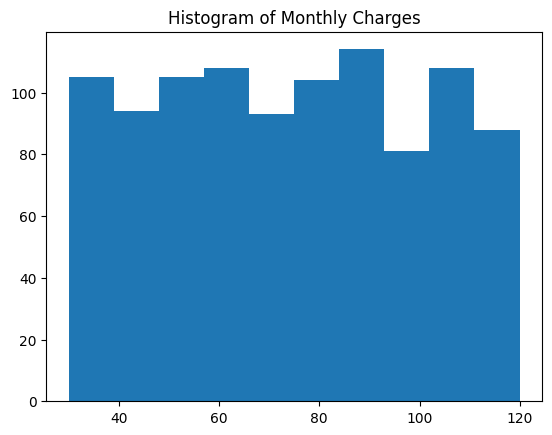

In [118]:
plt.hist(df['MonthlyCharges'])
plt.title("Histogram of Monthly Charges")
plt.show()

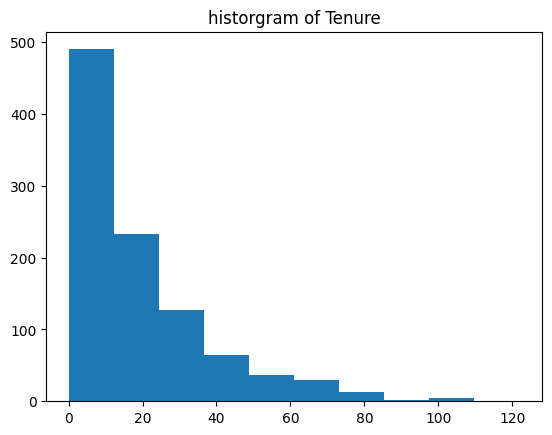

In [121]:
plt.hist(df['Tenure'])
plt.title('historgram of Tenure')

plt.savefig('charts/img_03')

Let's start doing Feature Engineering: